In [87]:
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf
import torch

from case_studies.sdss_galaxies_vae.reconstruction import load_models, reconstruct_scene_at_coordinates

In [3]:
import os
os.environ["BLISS_HOME"] = "/home/dereklh/projects/bliss/"

In [63]:
with initialize(config_path="../sdss_galaxies_vae/config", job_name="overlap"):
    cfg = compose(config_name="config", overrides=["models.prior.mean_sources=0.4"])   
    #print(OmegaConf.to_yaml(cfg))

simulated_dataset = instantiate(cfg.datasets.simulated)

In [64]:
simulated_dataset = instantiate(cfg.datasets.simulated)

In [131]:
batch_size=1
n_tiles_h=5
n_tiles_w=5
#tile_catalog = simulated_dataset.sample_prior(batch_size, n_tiles_h, n_tiles_w)
#torch.save(tile_catalog, "catalog.pt")
tile_catalog = torch.load("catalog.pt")

In [132]:
img, bg = simulated_dataset.simulate_image_from_catalog(tile_catalog)

In [133]:
import matplotlib.pyplot as plt

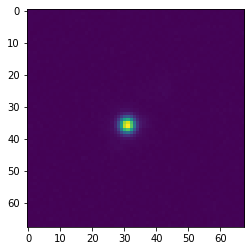

In [134]:
%matplotlib inline
plt.imshow(img[0, 0])

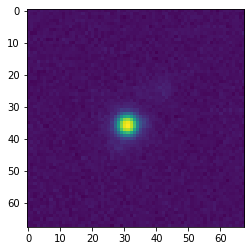

In [152]:

plt.imshow(img[0, 0].log())

In [135]:
tile_catalog["galaxy_params"].shape

torch.Size([1, 5, 5, 1, 7])

In [136]:
# load bliss
device = torch.device(cfg.reconstruct.device)
decoder, encoder, _ = load_models(cfg, device)
bp = 24
h, w = img.shape[2], img.shape[3]
# img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h-bp), (bp, w-bp))
img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 42.45it/s]


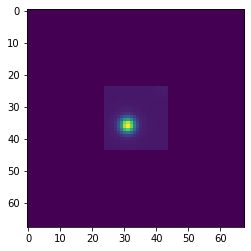

In [137]:
plt.imshow(torch.nn.functional.pad(img_recon[0, 0], (bp, bp, bp, bp)))

In [138]:
tile_map_recon.n_sources

tensor([[[0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 0, 0, 0]]], device='cuda:0')

In [139]:
tile_catalog.n_sources

tensor([[[0, 0, 1, 1, 1],
         [1, 0, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 1, 1, 0, 0],
         [1, 0, 0, 1, 0]]])

In [140]:
tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[1.8930e-02, 1.0945e-03, 6.2954e-04, 9.1496e-04, 9.0725e-01],
        [5.8966e-03, 4.6718e-03, 1.9195e-03, 9.9261e-04, 2.5686e-03],
        [4.5031e-03, 7.0185e-02, 1.6055e-02, 3.6303e-03, 3.5057e-04],
        [7.6984e-04, 9.7965e-01, 1.2336e-03, 2.2355e-02, 3.8939e-04],
        [1.3584e-03, 4.4039e-03, 2.7391e-02, 2.6265e-03, 1.3124e-03]],
       device='cuda:0')

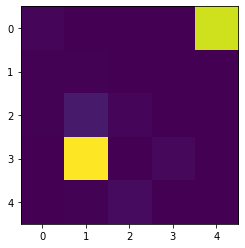

In [151]:
plt.imshow(tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

In [141]:
tile_map_recon.locs[0, 3, 1, 0]

tensor([0.0525, 0.8286], device='cuda:0')

In [142]:
tile_catalog.locs[0, 3, 1, 0]

tensor([0.0322, 0.8106])

In [143]:
tile_catalog2 = tile_catalog.copy()
tile_catalog2.locs = tile_catalog.locs.clone()
tile_catalog2.locs[0, 3, 1, 0] = 0.999

In [144]:
img2, bg2 = simulated_dataset.simulate_image_from_catalog(tile_catalog2)

In [145]:
img_recon2, tile_map_recon2 = reconstruct_scene_at_coordinates(encoder, decoder, img2, bg2, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 32.92it/s]


In [146]:

tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[2.0886e-04, 7.3117e-05, 9.7187e-04, 1.0478e-03, 9.7889e-01],
        [6.0804e-03, 2.6508e-03, 6.0823e-04, 1.2777e-03, 7.4880e-04],
        [3.8022e-03, 4.0674e-03, 3.6643e-03, 2.4801e-03, 1.0142e-03],
        [3.1788e-03, 1.1821e-01, 1.6972e-01, 7.2986e-03, 1.7525e-04],
        [1.2484e-03, 1.5023e-01, 9.1494e-02, 7.3674e-03, 9.4665e-05]],
       device='cuda:0')

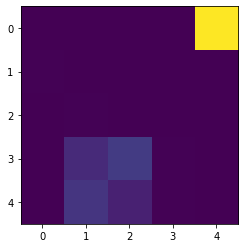

In [148]:
plt.imshow(tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())